<a href="https://colab.research.google.com/github/Vermont-Complex-Systems/storywrangler/blob/wiki-hedo/notebooks/instruments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U storywrangler

In [ ]:
# latest py-allotax version still on a branch
!pip install git+https://github.com/compstorylab/py-allotax.git@allotax-core

In [ ]:
# colab's slim Ubuntu image lacks Chrome's system libraries for writing the allotax plot
!apt-get -qq update && apt-get -qq install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libasound2 libgbm1 libnss3 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2

In [4]:
# local packages
from storywrangler import Storywrangler
from py_allotax import allotaxonograph

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [5]:
import storywrangler
print(storywrangler.__version__)

0.0.14


## Basics

In [6]:
client = Storywrangler()

In [7]:
bb = client.dataset("babynames", "ngrams")

Whenever working with instruments, it is worth knowing about [Storywrangler's open specifications](https://storywrangler.uvm.edu/specification) to boost the performance and interoperability of datasets. There are three key conventions:

- `data_schema.type`: setting this to types-counts means the dataset is compatible with the allotaxonometer instrument.
- `time-based` transforms: by declaring time, we know we can take time ranges or aggregate over the dataset.
- `entity-based`: an entity is a distinguishable person, place, organization, concept, event, or work referenced in a corpus (see [here](https://storywrangler.uvm.edu/specification#31-entity-identifier-systems) for more details).

They are optional but offer some guarantees and improve metadata completeness when specified.

In [ ]:
# here "year" has been declared as time-dimension
# while "sex" is a filter.
bb.meta['transform']

{'time_dimension': 'year',
 'filter_dimensions': ['sex'],
 'time_partitions': None,
 'hash_bucket': None,
 'hash_algorithm': 'murmur3_32',
 'hash_seed': 0}

In [ ]:
# Since we know "year" is a time columns,
# we introspect time range upon registration.
bb.availability

{'quebec': {'min': '1980', 'max': '2024', 'types': 1700},
 'united_states': {'min': '1880', 'max': '2024', 'types': 29225}}

In [ ]:
print(bb.meta["entity_mapping"])
print(bb.adapter)

{'local_id_column': 'geo', 'entity_namespace': 'wikidata'}
[{'local_id': 'united_states', 'entity_id': 'wikidata:Q30', 'entity_name': 'United States', 'entity_ids': ['iso:US', 'local:babynames:united_states']}, {'local_id': 'quebec', 'entity_id': 'wikidata:Q176', 'entity_name': 'Quebec', 'entity_ids': ['iso:CA-QC', 'local:babynames:quebec']}]


Here we can use either `local_id` or `entity_id` as entity in the `top_ngrams` query. Whenever using the standardized time-based system,

In [ ]:
ngram_data= bb.top_ngrams(
    entity="united_states",
    dates=1968, dates2=2018,
    sex="F",
    limit=bb.availability["united_states"]['types']
)

In [ ]:
df1=pd.DataFrame(ngram_data['1968'])
df2=pd.DataFrame(ngram_data['2018'])

In [ ]:
# Alpha = Inf
fig = allotaxonograph(df1, df2, "Inf", "Ω1: Baby girl names in 1968", "Ω2: Baby girl names in 2018")

In [ ]:
fig.interactive()

This figure is a replication of `Fig. 4` in _Allotaxonometry and rank-turbulence divergence: a universal instrument for comparing complex systems_ (Doods et al. 2023). Pretty cool!

In [ ]:
# saving the chart
fig.save("chart.pdf")

PDF saved to chart.pdf


## Shifterator

In [8]:
wiki = client.dataset("wikimedia", "ngrams")

In [17]:
shift = wiki.wordshift(
    entity="United States", dates="2025-01-01", dates2="2026-01-01",
    lexicon="labMT_English"
    )

In [18]:
shift.df()

,type,p_diff,s_diff,p_avg,s_ref_diff,shift_score
0,film,-0.000736,0.0,0.003086,1.187126,-0.022320
1,million,-0.000392,0.0,0.001260,2.007126,-0.020094
2,was,0.000595,0.0,0.016814,-0.772874,-0.011743
3,killed,-0.000086,0.0,0.000340,-3.812874,0.008367
4,album,0.000254,0.0,0.001664,1.227126,0.007959
...,...,...,...,...,...,...
195,invasion,-0.000019,0.0,0.000094,-1.952874,0.000962
196,than,-0.000059,0.0,0.001351,-0.632874,0.000957
197,musical,-0.000020,0.0,0.000337,1.847126,-0.000954
198,energy,-0.000020,0.0,0.000128,1.847126,-0.000954


## Server-side instruments

The platform can run the same computation for you: `/storywrangler/allotax` and `/storywrangler/rtd` work for **every** dataset registered as `types-counts`. Same comparison as above, no download:

In [ ]:
from IPython.display import Markdown

Markdown("""
  ```mermaid
graph LR
    A[Rust allotax-core] --> B[py03 binding]
    B --> D[Standalone library]
    B --> C[Storywrangler's API]
    C --> E[Server-side rendered]
  ```
""")


  ```mermaid
graph LR
    A[Rust allotax-core] --> B[py03 binding]
    B --> D[Standalone library]
    B --> C[Storywrangler's API]
    C --> E[Server-side rendered]
  ```


In [ ]:
result = bb.allotax(entity="wikidata:Q30", dates=1968, dates2=2018, sex="F", alpha="Inf")
result["wordshift"][:5]

[{'type': 'Lisa (1 ⇋ 1628.5)', 'metric': -0.05161095608631496},
 {'type': 'Liam (11970 ⇋ 1)', 'metric': 0.05161095608631496},
 {'type': 'Michelle (2 ⇋ 556)', 'metric': -0.02580547804315748},
 {'type': 'Emma (426.5 ⇋ 2)', 'metric': 0.02580547804315748},
 {'type': 'Kimberly (3 ⇋ 406)', 'metric': -0.01720365202877165}]

In [ ]:
# rtd is the lightweight variant: wordshift only, no diamond — fast enough for interactive use
rtd = bb.rtd(entity="wikidata:Q30", dates=1968, dates2=2018, sex="F")
rtd.df().head(10)

,type,rank1,rank2,divergence
0,Lisa,877.5,1.0,0.000603
1,Emma,1.0,426.5,-0.000582
2,Olivia,2.0,529.0,-0.000492
3,Michelle,263.0,2.0,0.000467
4,Ava,3.0,744.0,-0.000452
5,Isabella,4.0,2668.0,-0.000451
6,Kimberly,173.0,3.0,0.000397
7,Harper,9.0,11862.0,-0.000395
8,Jennifer,344.0,4.0,0.000391
9,Tammy,4037.0,8.0,0.000387


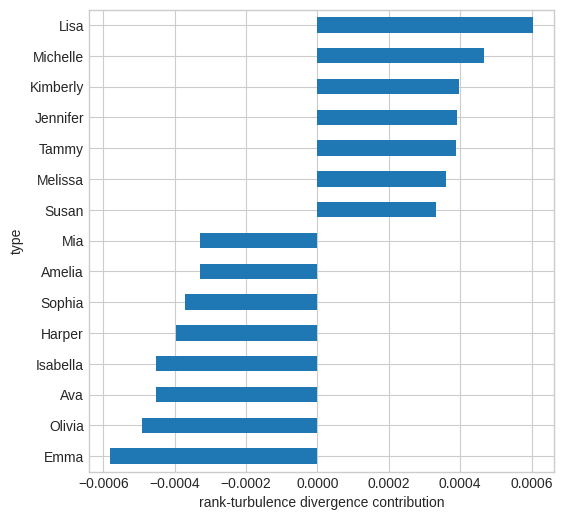

In [ ]:
# which names moved most between 1968 and 2018?
ws = rtd.df().head(15).set_index("type")
ws["divergence"].sort_values().plot.barh(figsize=(6, 6))
plt.xlabel("rank-turbulence divergence contribution");

### The alpha parameter

`alphas=` computes several alphas in one request. Low alpha weighs rank *churn* across the
whole distribution; alpha=inf only sees types that displace the very top.

In [ ]:
multi = bb.rtd(entity="wikidata:Q30", dates=1968, dates2=2018, sex="F",
               alphas="0, 0.25,1,inf", wordshift_limit=5)
[(a["alpha"], a["wordshift"][0]["type"]) for a in multi["alpha_results"]]

[(0.0, 'Harper'), (0.25, 'Lisa'), (1.0, 'Lisa'), ('Infinity', 'Emma')]

## Instruments are engine-agnostic

The classic Twitter corpus is served straight from MongoDB — the instrument neither knows nor cares. Same method, same response shape:

In [ ]:
tw = client.dataset("twitter")
tw.rtd(dates="2020-03-15", dates2="2020-02-15", lang="en", wordshift_limit=5).df()

,type,rank1,rank2,divergence
0,coronavirus,1469.0,79.0,0.000162
1,pandemic,11468.5,188.0,0.000162
2,virus,2282.0,99.0,0.000161
3,COVID-19,11468.5,202.0,0.000158
4,➫,205.0,11468.5,-0.000157


In [ ]:
# datasets can register several count measures — ?weight= picks one.
# with retweets the top mover is a K-pop hashtag (RT armies); without them, the pandemic:
tw.rtd(dates="2020-03-15", dates2="2020-02-15", lang="en",
       weight="count_noRT", wordshift_limit=5).df()

,type,rank1,rank2,divergence
0,#NCT127,10750.5,360.0,0.000129
1,virus,2077.0,165.0,0.000129
2,#NCT127_KickIt,9779.0,361.0,0.000127
3,#엔시티,10750.5,396.0,0.000125
4,pandemic,10750.5,478.0,0.000117


## Varying attention mechanisms

In [ ]:
reddit = client.dataset("reddit")

In [ ]:
reddit.meta['data_schema']

{'ngram': 'VARCHAR',
 'date': 'DATE',
 'comments_score_weighted': 'FLOAT',
 'comments_controversy_weighted': 'FLOAT',
 'comments_unweighted': 'INTEGER',
 'comments_score_freq': 'FLOAT',
 'comments_controversy_freq': 'FLOAT',
 'comments_unweighted_freq': 'FLOAT',
 'submissions_score_weighted': 'FLOAT',
 'submissions_controversy_weighted': 'FLOAT',
 'submissions_unweighted': 'INTEGER',
 'submissions_score_freq': 'FLOAT',
 'submissions_controversy_freq': 'FLOAT',
 'submissions_unweighted_freq': 'FLOAT',
 'all_score_weighted': 'FLOAT',
 'all_controversy_weighted': 'FLOAT',
 'all_score_freq': 'FLOAT',
 'all_controversy_freq': 'FLOAT',
 'rank': 'INTEGER',
 'top_subreddits': 'STRUCT(subreddit VARCHAR, score_weighted FLOAT)[]',
 'lang': 'VARCHAR',
 'month': 'BIGINT',
 'n': 'BIGINT',
 'year': 'BIGINT'}

In [ ]:
dft1=reddit.term_series(
       window=365*3, type="Trump", lang="en", n=1,
       weight="comments_controversy_weighted").df().set_index("date")['counts']

dft2=reddit.term_series(
       window=365*3, type="Trump", lang="en", n=1,
       weight="submissions_controversy_weighted").df().set_index("date")['counts']

merged_df = pd.merge(dft1,dft2,on="date", suffixes=["_comments", "_submission"])

In [ ]:
dfb1=reddit.term_series(
       window=365*3, type="Biden", lang="en", n=1,
       weight="comments_controversy_weighted").df().set_index("date")['counts']

dfb2=reddit.term_series(
       window=365*3, type="Biden", lang="en", n=1,
       weight="submissions_controversy_weighted").df().set_index("date")['counts']

merged_dfb = pd.merge(dfb1,dfb2,on="date", suffixes=["_comments", "_submission"])

In [ ]:
multi_df = pd.merge(merged_df,merged_dfb,on="date", suffixes=["_trump", "_biden"])

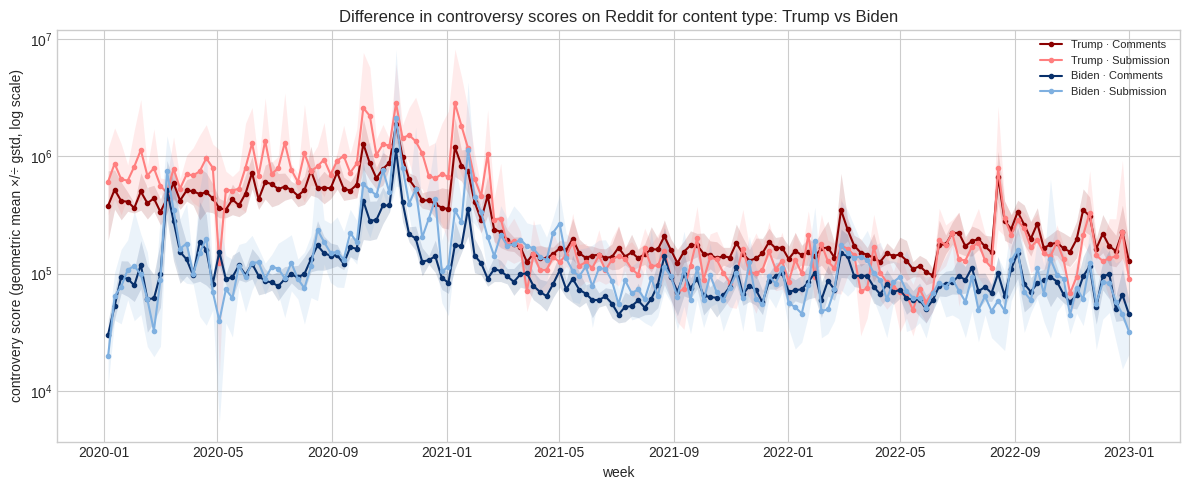

In [ ]:
multi_df.index = pd.to_datetime(multi_df.index)
df = multi_df.sort_index()

# geometric mean & geometric std, computed in log space
logdf = np.log(df)
center = np.exp(logdf.resample("W").mean())          # geometric mean
gsd    = np.exp(logdf.resample("W").std())           # geometric std (a ratio, ≥1)
upper  = center * gsd
lower  = center / gsd

styles = {
    "counts_comments_trump": dict(color="#8B0000", label="Trump · Comments"),
    "counts_submission_trump":  dict(color="#FF7F7F", label="Trump · Submission"),
    "counts_comments_biden": dict(color="#08306B", label="Biden · Comments"),
    "counts_submission_biden":  dict(color="#7FB0E0", label="Biden · Submission"),
}

fig, ax = plt.subplots(figsize=(12, 5))
for col, st in styles.items():
    ax.plot(center.index, center[col], marker="o", ms=3,
            color=st["color"], label=st["label"])
    ax.fill_between(center.index, lower[col], upper[col],
                    color=st["color"], alpha=0.15, linewidth=0)

ax.set_yscale("log")
ax.set_ylabel("controvery score (geometric mean ×/÷ gstd, log scale)")
ax.set_xlabel("week")
ax.set_title("Difference in controversy scores on Reddit for content type: Trump vs Biden")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show();

## Every result carries its provenance

An instrument result is a function of the **instrument version**, the **data version**, and the **parameters** — change any of the three and the numbers can change. So every response records all three in `meta`: `allotax_version` pins the library (immutable on PyPI), `dataset_version` names the registry slot, and the parameters (plus `types_target`/`types_ref`, the number of types actually loaded) make the record complete. Rerun later and compare: if the types counts moved, the data changed under you.

In [ ]:
rtd["meta"]

{'entity': 'wikidata:Q30',
 'dates': '1968',
 'dates2': '2018',
 'alpha': 0.25,
 'domain': 'babynames',
 'dataset': 'ngrams',
 'dataset_version': 'latest',
 'filters': {'sex': 'F'},
 'ngram_limit': 10000,
 'wordshift_limit': 10000,
 'types_target': 8198,
 'types_ref': 10000,
 'allotax_version': '0.3.2'}

Datasets can also cut **immutable snapshots** (`version="1.0.0"`): the mutable `latest` slot keeps moving with the pipeline, while a snapshot freezes the registration — and, for datasets like babynames whose file list is copy-on-write, the exact bytes — forever. That is what makes `dataset_version` citable in a paper.

In [ ]:
[(v["version"], v["created_at"][:10]) for v in bb.versions()["versions"]]

[('1.0.0', '2026-07-21'), ('latest', '2026-04-07')]